In [ ]:
import sys

from typing import List, TypedDict, Literal
from pydantic import BaseModel
import re
from langgraph.graph import StateGraph,END,START
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate


from langgraph.graph import StateGraph, START, END


from langchain_community.tools.tavily_search import TavilySearchResults


C:\Users\karan\AppData\Local\Temp\ipykernel_19792\1525442646.py:7: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
c:\Users\karan\Desktop\clean desktop\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


False

In [2]:
import operator
from typing import List, TypedDict, Annotated
from langchain_core.messages import BaseMessage


class ChatState(TypedDict):
    # Original user question
    question: str

    # Tasks generated by planner
    research_tropics_planned: List[str]

    # Research findings from parallel researchers
    # Each researcher returns a list, and operator.add merges them
    research_results: Annotated[List[str], operator.add]

    # Research collected/organized by collector
    collected_researchs: List[dict]

    # Critic output
    # Critique is a single value, so no reducer is needed
    critique: str

    # Final report generated by report writer
    final_report: str

    # Path of saved markdown report
    saved_file_path: str

    # Conversation/tool messages
    messages: Annotated[List[BaseMessage], operator.add]

    # Tracks whether web search was used
    # operator.or_ allows parallel researchers to merge True values
    web_search_performed: Annotated[bool, operator.or_]

    # Report containing [[IMAGE_1]], [[IMAGE_2]], etc.
    md_with_placeholders: str

    # Image generation specifications
    image_specs: List[dict]

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()
HF_TOKEN = os.getenv("HF_TOKEN")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
GOOGLE_API_KEY2 = os.getenv("GOOGLE_API_KEY2")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

my_api_tuple = (HF_TOKEN, GOOGLE_API_KEY, GOOGLE_API_KEY,GROQ_API_KEY)
if not all(my_api_tuple):
     raise ValueError("HF_TOKEN not found in .env")
print('all env loaded successfully')

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI


# Main LLM
google_llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    api_key=GOOGLE_API_KEY,
)


# Second LLM
# Used where you want a separate model/configuration.
google_llm_secondary = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    api_key=GOOGLE_API_KEY2,
)

In [5]:
from langchain_groq import ChatGroq

groq_llm = ChatGroq(
    model="openai/gpt-oss-120b",  # or "llama-3.1-8b-instant"
    temperature=0.2,
    max_retries=2,
    api_key=GROQ_API_KEY
)




In [6]:
from typing import TypedDict, List
from langchain_core.prompts import ChatPromptTemplate


class PlannerState(TypedDict):
    research_tasks: List[str]


def planner(state: ChatState) -> dict:
    question = state["question"]

    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            """
You are an expert research planning agent.

Break the user's research question into exactly 3 clear,
specific, independent research tasks.

Rules:
- Each task must investigate a different aspect of the question.
- Tasks must be specific enough for a researcher to execute.
- Avoid overlapping tasks.
- Do not answer the user's question.
- Return only the research tasks.
"""
        ),
        (
            "human",
            "{question}"
        )
    ])

    planner_chain = (
        prompt
        | google_llm.with_structured_output(PlannerState)
    )

    response = planner_chain.invoke({
        "question": question
    })

    tasks = response.get("research_tasks", [])

    if not tasks:
        raise ValueError("Planner returned no research tasks.")

    return {
        "research_tropics_planned": tasks[:3]
    }

In [8]:
from pydantic import BaseModel, Field
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
from typing import List


class WebSearchInput(BaseModel):
    queries: List[str] = Field(
        description="A list of web search queries to run."
    )


tavily_search = TavilySearch(
    max_results=5,
    topic="general",
    tavily_api_key=TAVILY_API_KEY
)


@tool(args_schema=WebSearchInput)
def web_search(queries: List[str]) -> str:
    """Search the web for current, missing, or detailed information."""
    all_results = []
    for query in queries:
        result = tavily_search.invoke({"query": query})
        all_results.append(f"Query: {query}\nResult: {result}")
    return "\n\n---\n\n".join(all_results)


tools = [web_search]


In [9]:
research_llm = google_llm.bind_tools(tools)

In [10]:
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage


def _content_to_str(content) -> str:
    """Normalize Gemini response.content (str or list of parts) to a plain string."""
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        parts = []
        for part in content:
            if isinstance(part, dict):
                parts.append(part.get("text", str(part)))
            else:
                parts.append(str(part))
        return " ".join(parts)
    return str(content)


def researcher(state: ChatState) -> dict:
    task = state.get("task") or state.get("question") or "Research topic"

    messages = [
        SystemMessage(
            content=(
                "You are an expert research agent.\n"
                "Research ONLY the provided research task.\n"
                "Use web_search when current or external information is required.\n"
                "When enough information is available, provide a highly detailed, comprehensive, and lengthy research finding. Extract all key details, examples, and data. Do not summarize briefly."
            )
        ),
        HumanMessage(content=f"Research task:\n{task}")
    ]

    response = research_llm.invoke(messages)
    web_search_performed = False

    if response.tool_calls:
        web_search_performed = True
        messages.append(response)

        for tool_call in response.tool_calls:
            if tool_call["name"] == "web_search":
                tool_output = web_search.invoke(tool_call["args"])
                messages.append(ToolMessage(
                    content=str(tool_output),
                    tool_call_id=tool_call["id"]
                ))

        response = research_llm.invoke(messages)

    content_str = _content_to_str(response.content)
    return {
        "research_results": [content_str] if content_str else [],
        "web_search_performed": web_search_performed,
    }


In [11]:
from langgraph.types import Send


def assign_tasks(state: ChatState):
    topics = state.get("research_tropics_planned") or []

    return [
        Send("researcher", {"task": topic})
        for topic in topics
    ]

In [12]:
def collector(state: ChatState):
    raw_results = state["research_results"]
    question = state["question"]

    # Format the collected findings into a clear text block
    formatted_findings = "\n\n---\n\n".join(
        f"Finding {idx + 1}:\n{result}"
        for idx, result in enumerate(raw_results)
    )

    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            """You are an Evidence Collector agent.
Your job is to read all raw research findings gathered by multiple researchers and organize them.

Tasks:
1. Deduplicate repeating information across findings.
2. Group related facts into clear, logical categories.
3. Keep all key details, facts, numbers, and references intact.
4. Do NOT attempt to answer the user's original question directly or write the final report yet.

Focus purely on structuring and consolidating the evidence clearly."""
        ),
        (
            "human",
            "User Question: {question}\n\nRaw Findings:\n{findings}"
        )
    ])

    collector_chain = prompt | google_llm_secondary
    response = collector_chain.invoke({
        "question": question,
        "findings": formatted_findings
    })

    return {
        "collected_researchs": [{"text": _content_to_str(response.content)}]
    }


In [13]:
from pydantic import BaseModel, Field


class CriticState(BaseModel):

    is_sufficient: bool

    key_strengths: list[str]

    missing_gaps: list[str]

    feedback_for_writer: str

    overall_score: int = Field(
        ge=0,
        le=10
    )


def critic(state: ChatState) -> dict:

    question = state["question"]

    evidence = state["collected_researchs"]

    evidence_text = "\n\n".join(
        item["text"]
        for item in evidence
    )

    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                """
You are a QA critic for a deep research system.

Evaluate the evidence ONLY against the user's question.
Do not add facts or use outside knowledge.

Check:

- Relevance
- Completeness
- Quality
- Consistency
- Clarity

Score 0-10:

0-2 = very poor
3-4 = major gaps
5-6 = moderate
7-8 = strong
9-10 = comprehensive

Set is_sufficient=True only if the main question
is answered and there are no major gaps.

Generally, this requires a score >= 7.

Be critical and concise.
Do not invent information.
"""
            ),
            (
                "human",
                """
Question:

{question}

Evidence:

{evidence}
"""
            )
        ]
    )

    critic_chain = (
        prompt
        | google_llm.with_structured_output(
            CriticState
        )
    )

    response = critic_chain.invoke(
        {
            "question": question,
            "evidence": evidence_text
        }
    )

    key_strengths = (
        "\n- ".join(response.key_strengths)
        if response.key_strengths
        else "None"
    )

    missing_gaps = (
        "\n- ".join(response.missing_gaps)
        if response.missing_gaps
        else "None"
    )

    formatted_critique = f"""
Sufficient Evidence: {response.is_sufficient}

Overall Score: {response.overall_score}/10

Key Strengths:
- {key_strengths}

Missing Gaps:
- {missing_gaps}

Feedback for Report Writer:
{response.feedback_for_writer}
""".strip()

    return {
        "critique": formatted_critique
    }

In [14]:
def report_writer(state: dict):
    question = state.get("question", "")

    evidence = (
        state.get("collected_researchs", [{}])[-1].get("text")
        or state.get("research_results", [""])[-1]
        or "No research evidence gathered."
    )

    critique = state.get("critique", "No critique provided.")

    # Evidence ko clean text format mein convert karo
    if isinstance(evidence, list):
        formatted_evidence = "\n\n---\n\n".join(map(str, evidence))
    else:
        formatted_evidence = str(evidence)

    # Detailed report prompt
    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            """You are a Senior Technical Research Writer and Research Analyst.

Your job is to transform the provided research evidence and critic feedback
into a detailed, authoritative, well-structured Markdown research report.

IMPORTANT REPORT REQUIREMENTS:

1. LENGTH AND DEPTH
- Write a detailed report, not a short summary.
- Aim for approximately 1000–1500 words when sufficient evidence is available.
- Do not artificially repeat information just to increase length.
- Every section should provide useful technical information.
- Explain important concepts instead of merely mentioning them.

2. STRUCTURE

Use this structure when appropriate:

# [Clear Report Title]

## Executive Summary
Provide a concise overview of the main findings.

## 1. Introduction
Explain the topic and why it matters in the context of the user's question.

## 2. Core Concepts
Explain the fundamental concepts required to understand the topic.
Define important technical terms clearly.

## 3. Detailed Analysis
Break the main topic into logical subsections.
Explain each part thoroughly.

## 4. Technical Workflow / Architecture
If the topic involves a system, pipeline, architecture, or process,
explain the flow step-by-step.

Use numbered steps where appropriate.

## 5. Practical Examples
Give concrete examples wherever they improve understanding.
Use code snippets or pseudo-code only when genuinely useful.

## 6. Advantages and Limitations
Discuss both strengths and weaknesses.
Do not present the technology as universally perfect.

## 7. Key Findings
Summarize the most important findings from the research evidence.

## 8. Conclusion
Provide a clear conclusion directly answering the user's original question.

3. EVIDENCE USAGE
- Use the provided research evidence as the primary source of information.
- Cover all important findings from the evidence.
- Do not ignore relevant evidence.
- Do not invent research findings that are not supported by the evidence.
- If evidence is incomplete, explicitly state the limitation.

4. CRITIC FEEDBACK
- Carefully examine the critic feedback.
- Fix gaps, inaccuracies, missing explanations, or weak areas identified by the critic.
- Do not blindly copy the critique into the report.
- Use the critique to improve the final report.

5. WRITING STYLE
- Professional and technical.
- Clear and easy to understand.
- Avoid unnecessary repetition.
- Avoid generic filler.
- Start directly with useful information.
- Use Markdown headings, bullets, numbered lists, tables, and bold text where useful.
- Prefer explanation over vague statements.

6. TECHNICAL ACCURACY
- Do not fabricate facts, statistics, citations, sources, or research findings.
- Clearly distinguish established information from uncertainty.
- When the evidence does not support a claim, do not present it as a fact.

7. FINAL ANSWER
The final output must contain ONLY the Markdown research report.
Do not include comments such as:
"Here is your report"
"Based on the evidence"
"I hope this helps"
or similar meta commentary."""
        ),
        (
            "human",
            """Original Research Question:
{question}

Quality Assurance Critique:
{critique}

Collected Research Evidence:
{evidence}

Now write the final detailed research report.

Make sure the report:
- Directly answers the original question.
- Is approximately 1000–1500 words when enough evidence is available.
- Explains the important concepts in depth.
- Includes appropriate sections and subsections.
- Incorporates the critic's feedback.
- Uses the research evidence thoroughly.
- Includes examples or technical workflow explanations where useful.
- Ends with a clear conclusion."""
        )
    ])

    writer_chain = prompt | groq_llm

    response = writer_chain.invoke({
        "question": question,
        "critique": critique,
        "evidence": formatted_evidence
    })

    return {
        "final_report": _content_to_str(response.content)
    }

In [15]:
from typing import List, Literal
from pydantic import BaseModel, Field


class ImageSpec(BaseModel):

    placeholder: str = Field(
        ...,
        description="e.g. [[IMAGE_1]]"
    )

    filename: str = Field(
        ...,
        description="Save under images/, e.g. qkv_flow.png"
    )

    alt: str

    caption: str

    prompt: str = Field(
        ...,
        description="Prompt to send to the image model."
    )

    size: Literal[
        "1024x1024",
        "1024x1536",
        "1536x1024"
    ] = "1024x1024"

    quality: Literal[
        "low",
        "medium",
        "high"
    ] = "medium"


class GlobalImagePlan(BaseModel):

    md_with_placeholders: str

    images: List[ImageSpec] = Field(
        default_factory=list
    )

In [16]:
from langchain_core.messages import (
    SystemMessage,
    HumanMessage,
)


DECIDE_IMAGES_SYSTEM = """
You are an expert technical editor.

Decide whether images or diagrams are needed for THIS report.

Rules:

- Maximum 3 images.
- Only create images that materially improve understanding.
- Prefer technical diagrams, workflows, architecture diagrams,
  pipelines, comparisons, or conceptual visuals.
- Do NOT create decorative images.

Insert placeholders exactly:

[[IMAGE_1]]
[[IMAGE_2]]
[[IMAGE_3]]

If no images are needed:

md_with_placeholders must equal the input report
and images must be [].

Return strictly GlobalImagePlan.
"""


def decide_images(state: ChatState) -> dict:

    planner = google_llm.with_structured_output(
        GlobalImagePlan
    )

    report = state["final_report"]

    image_plan = planner.invoke(
        [
            SystemMessage(
                content=DECIDE_IMAGES_SYSTEM
            ),

            HumanMessage(
                content=(
                    "Research question:\n"
                    f"{state['question']}\n\n"

                    "Final report:\n"
                    f"{report}\n\n"

                    "Decide whether useful images are needed."
                )
            ),
        ]
    )

    return {
        "md_with_placeholders":
            image_plan.md_with_placeholders,

        "image_specs": [
            img.model_dump()
            for img in image_plan.images
        ],
    }

In [18]:
from io import BytesIO
from huggingface_hub import InferenceClient


IMAGE_SYSTEM_PROMPT = """
You are an expert technical diagram and architecture illustrator.

Your job is to create accurate, professional, easy-to-read technical diagrams.

Rules:
- Follow the requested architecture exactly.
- Show clear relationships and data flow between components.
- Use short, readable labels.
- Keep the layout clean and logically organized.
- Use arrows to show direction of data or control flow.
- Use a professional documentation/technical-architecture style.
- Avoid unnecessary decorative elements.
- Do not invent components that were not requested.
- Do not change technical terminology.
- Prioritize technical accuracy and readability over artistic decoration.
"""


def generate_image_bytes(prompt: str) -> bytes:

    client = InferenceClient(
        api_key=HF_TOKEN,
        provider="auto"
    )

    final_prompt = f"""
{IMAGE_SYSTEM_PROMPT}

USER IMAGE REQUEST:
{prompt}
"""

    image = client.text_to_image(
        prompt=final_prompt,
        model="Qwen/Qwen-Image"
    )

    buffer = BytesIO()
    image.save(buffer, format="PNG")

    return buffer.getvalue()

In [19]:
from pathlib import Path


def generate_and_place_images(
    state: ChatState
) -> dict:

    md = (
        state.get("md_with_placeholders")
        or state["final_report"]
    )

    image_specs = (
        state.get("image_specs")
        or []
    )

    # -----------------------------
    # No images required
    # -----------------------------

    if not image_specs:

        return {
            "final_report": md
        }

    # -----------------------------
    # Images directory
    # -----------------------------

    images_dir = Path("images")

    images_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    # -----------------------------
    # Generate images
    # -----------------------------

    for spec in image_specs:

        placeholder = spec["placeholder"]
        filename = spec["filename"]

        out_path = (
            images_dir / filename
        )

        try:

            # -------------------------
            # Generate only if missing
            # -------------------------

            if not out_path.exists():

                image_bytes = generate_image_bytes(
                    spec["prompt"]
                )

                out_path.write_bytes(
                    image_bytes
                )

            # -------------------------
            # Markdown image
            # -------------------------

            image_markdown = (
                f"![{spec['alt']}]"
                f"(images/{filename})\n\n"
                f"*{spec['caption']}*"
            )

            md = md.replace(
                placeholder,
                image_markdown
            )

        except Exception as e:

            print(
                f"Image generation failed "
                f"for {filename}: {e}"
            )

            fallback = (
                "\n\n"
                "> **Image generation failed**\n"
                ">\n"
                f"> {spec.get('caption', '')}\n"
                ">\n"
                f"> Error: {e}\n"
            )

            md = md.replace(
                placeholder,
                fallback
            )

    return {
        "final_report": md
    }

In [20]:
# AFTER
from typing import TypedDict, List

class ImageSubgraphState(TypedDict):
    question: str           # ← add this
    final_report: str
    md_with_placeholders: str
    image_specs: List[dict]

def build_image_subgraph():
    image_graph = StateGraph(ImageSubgraphState)   # ← isolated state, no conflict
    image_graph.add_node("decide_images", decide_images)
    image_graph.add_node("generate_images", generate_and_place_images)
    image_graph.add_edge(START, "decide_images")
    image_graph.add_edge("decide_images", "generate_images")
    image_graph.add_edge("generate_images", END)
    return image_graph.compile()

image_subgraph = build_image_subgraph()


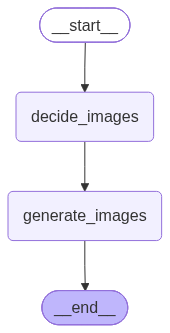

In [21]:
image_subgraph

In [34]:
import re
from pathlib import Path


def file_saver(state: ChatState) -> dict:

    report_content = state["final_report"]
    question = state["question"]

    # --------------------------------
    # Make question a string
    # --------------------------------
    if isinstance(question, dict):
        question = (
            question.get("question")
            or question.get("text")
            or str(question)
        )
    question = str(question)

    # --------------------------------
    # Make final report a string
    # --------------------------------
    if isinstance(report_content, list):
        report_content = "\n\n".join(
            str(item.get("text", item) if isinstance(item, dict) else item)
            for item in report_content
        )
    elif isinstance(report_content, dict):
        report_content = report_content.get("text", str(report_content))
    else:
        report_content = str(report_content)

    # --------------------------------
    # Add AI Warning & Disclaimer Banner
    # --------------------------------
    warning_banner = (
        "> ⚠️ **AI Disclaimer & Warning:**\n"
        "> This report was autonomously generated by an AI research assistant. "
        "AI models can make mistakes, hallucinate details, or generate inaccurate, "
        "outdated, or unnecessary content. Please independently verify critical facts, "
        "citations, and technical claims before relying on this document.\n\n---\n\n"
    )

    # Prepend warning to report
    final_saved_content = warning_banner + report_content

    # --------------------------------
    # Create safe filename
    # --------------------------------
    safe_title = re.sub(
        r"[^a-zA-Z0-9]+",
        "_",
        question.strip().lower()
    )
    safe_title = re.sub(
        r"_+",
        "_",
        safe_title
    ).strip("_")

    safe_title = safe_title[:50].rstrip("_")

    if not safe_title:
        safe_title = "research_report"

    # --------------------------------
    # Create reports directory & Save
    # --------------------------------
    output_dir = Path("reports")
    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    output_path = (
        output_dir /
        f"{safe_title}_report.md"
    )

    output_path.write_text(
        final_saved_content,
        encoding="utf-8"
    )

    return {
        "saved_file_path": str(output_path)
    }


In [23]:
from langgraph.types import interrupt, Command
def human_review(state: ChatState) -> dict:

    review = interrupt({
        "type": "human_review",
        "message": "Your research report is ready. Please review it before saving.",
        "question": state["question"],
        "final_report": state["final_report"],
        "image_specs": state.get("image_specs", [])
    })

    if review != "approve":
        raise ValueError(
            "Report was not approved for saving."
        )

    return {}

In [24]:
g = StateGraph(ChatState)

# Nodes (Removed ToolNode)
g.add_node("planner", planner)
g.add_node("researcher", researcher)
g.add_node("collector", collector)
g.add_node("critic", critic)
g.add_node("report_writer", report_writer)
g.add_node('image_subgraph', image_subgraph)
g.add_node("file_saver", file_saver)

# Edges
g.add_edge(START, "planner")

# Route parallel tasks to researchers
g.add_conditional_edges(
    "planner",
    assign_tasks,
    ["researcher"]
)

# Parallel researchers go directly to the collector!
g.add_edge("researcher", "collector")

# Linear flow for the rest
g.add_edge("collector", "critic")
g.add_edge("critic", "report_writer")
g.add_edge("report_writer", "image_subgraph")
g.add_edge("image_subgraph", "file_saver")
g.add_edge("file_saver", END)


In [25]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()

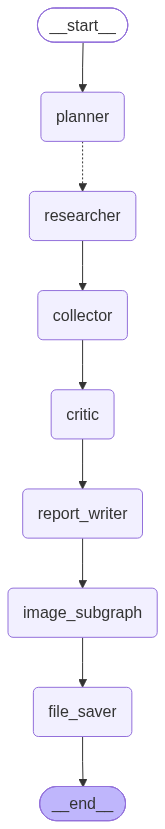

In [26]:
workflow = g.compile(checkpointer=checkpointer)
workflow

In [27]:
config = {
    "configurable": {
        "thread_id": "research_004"
    }
}
question = "Optimizing Edge AI and Lightweight Computer Vision Architectures for Real-Time, Offline Accessibility Tools."

In [28]:
for chunk in workflow.stream(
    {
        "question": question,
        "task": "",
        "research_tropics_planned": [],
        "research_results": [],
        "collected_researchs": [],
        "critique": "",
        "final_report": "",
        "saved_file_path": "",
        "messages": [],
        "web_search_performed": False,
        "md_with_placeholders": "",
        "image_specs": []
    },
    config=config,
    stream_mode="updates"
):                          # ‚Üê Add this colon
    print("\n--- UPDATE ---")
    print(chunk)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.



--- UPDATE ---
{'planner': {'research_tropics_planned': ['Evaluate the performance-to-latency trade-offs of current state-of-the-art lightweight backbone architectures like MobileNetV4, EfficientFormer, and TinyViT for real-time inference on resource-constrained edge hardware.', 'Analyze effective model compression techniques including weight quantization, knowledge distillation, and structural pruning specifically designed to maintain high accuracy for offline accessibility-focused computer vision tasks.', 'Investigate hardware-aware optimization frameworks such as TensorFlow Lite, ONNX Runtime, and TVM to maximize throughput and minimize power consumption for real-time vision processing on mobile and embedded edge devices.']}}

--- UPDATE ---
{'researcher': {'research_results': ['To maximize throughput and minimize power consumption for real-time vision processing on mobile and embedded edge devices, developers must move beyond model design to system-level, hardware-aware optimizati

In [29]:
# user_input = input(chunk['__interrupt__'][-1].value)

In [30]:
# result = workflow.invoke(
#     Command(
#         resume="approve"
#     ),
#     config=config
# )

In [31]:
# result

In [32]:
chunk.keys()

dict_keys(['file_saver'])

In [33]:
out['research_tropics_planned']

NameError: name 'out' is not defined

In [ ]:
out['collected_researchs'][-1]

In [ ]:
out['research_results'][-1][0]['text']